In [11]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Datafull train.csv', sep=';')
df

,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,char
0,449.894,638.530,329.537,588.029,262.366,475.709,253.967,343.421,247.663,236.477,...,475.346,591.398,426.475,592.339,341.419,548.671,413.658,541.039,454.239,NaN
1,459.426,638.641,347.614,599.550,273.522,486.969,262.374,354.810,248.102,248.011,...,471.021,587.605,425.540,598.047,337.165,559.660,410.858,548.164,455.238,A
2,444.194,659.268,326.598,616.910,253.226,497.914,243.082,361.876,239.491,259.676,...,476.613,560.803,418.030,567.584,346.090,533.656,416.844,524.283,450.811,A
3,443.780,650.429,324.970,607.825,252.818,487.201,244.345,356.561,243.655,256.638,...,473.187,573.173,418.568,580.205,339.026,541.187,411.295,528.062,445.777,A
4,452.860,638.769,340.436,595.407,272.323,487.497,254.365,357.569,231.482,241.993,...,463.566,577.341,425.073,581.486,337.553,551.375,410.228,546.574,449.936,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32844,438.216,475.728,384.271,438.175,365.128,370.238,359.100,308.232,341.079,263.943,...,393.282,526.248,369.550,542.888,314.872,553.693,291.555,565.394,270.450,Y
32845,451.700,471.125,388.505,420.364,370.429,366.011,359.194,301.358,338.958,255.391,...,394.962,523.331,378.997,544.635,321.277,556.352,292.890,574.840,273.024,Y
32846,461.909,469.288,400.524,424.948,372.224,372.311,353.600,310.913,326.736,261.919,...,394.474,534.607,373.414,555.518,319.473,570.948,285.517,586.932,256.553,Y
32847,451.633,470.803,393.561,427.040,365.993,371.472,349.987,306.755,324.605,257.534,...,390.126,524.399,378.125,548.321,321.545,566.286,289.032,585.819,261.687,Y


In [3]:
df['char'].value_counts()

char
P    1677
Q    1486
R    1485
V    1415
Y    1403
W    1398
X    1385
U    1363
F    1360
H    1356
N    1355
T    1351
D    1346
E    1345
C    1345
K    1329
B    1327
L    1318
M    1317
G    1317
A    1312
O    1310
S    1302
I    1223
Name: count, dtype: int64

In [4]:
df.isnull().sum()

0x       0
0y       0
1x       0
1y       0
2x       0
2y       0
3x       0
3y       0
4x       0
4y       0
5x       0
5y       0
6x       0
6y       0
7x       0
7y       0
8x       0
8y       0
9x       0
9y       0
10x      0
10y      0
11x      0
11y      0
12x      0
12y      0
13x      0
13y      0
14x      2
14y      2
15x      2
15y      7
16x      2
16y      3
17x      5
17y      1
18x      0
18y      1
19x      0
19y      0
20x      0
20y      0
char    24
dtype: int64

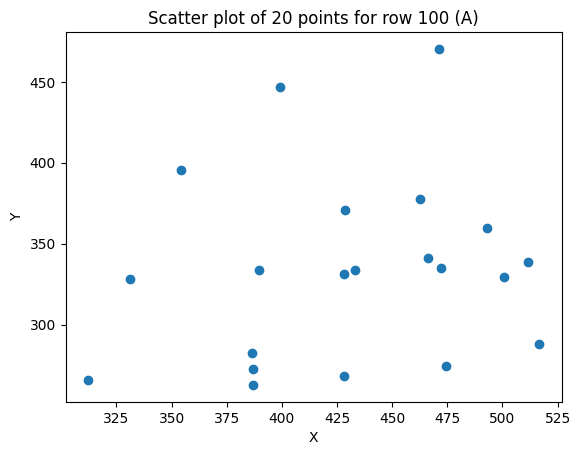

In [5]:
df_test = df.drop(columns='char')
row = 100
plot_row = df_test.iloc[row]

xs = plot_row.filter(regex=r'x$').values
ys = plot_row.filter(regex=r'y$').values

# Scatter plot
plt.scatter(xs, ys)
plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"Scatter plot of 20 points for row {row} ({df['char'].iloc[row]})")
plt.show()

In [6]:
char = df['char'].unique()
char

array([nan, 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M',
       'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y'],
      dtype=object)

## **Cleaning**

In [7]:
df = df.dropna()

In [8]:
df.isnull().sum()

0x      0
0y      0
1x      0
1y      0
2x      0
2y      0
3x      0
3y      0
4x      0
4y      0
5x      0
5y      0
6x      0
6y      0
7x      0
7y      0
8x      0
8y      0
9x      0
9y      0
10x     0
10y     0
11x     0
11y     0
12x     0
12y     0
13x     0
13y     0
14x     0
14y     0
15x     0
15y     0
16x     0
16y     0
17x     0
17y     0
18x     0
18y     0
19x     0
19y     0
20x     0
20y     0
char    0
dtype: int64

## **Preprocessing**

In [18]:
X = df.drop(columns='char')
y = df['char']

In [19]:
X_np = X.to_numpy()
X_norm = []

for row in X_np:
    # Reshape the flat 42-length row into 21 pairs of (x, y) coordinates
    pts = row.reshape(21, 2)

    # 1. Center the points (Exact match to app.py)
    center = np.mean(pts, axis=0)
    norm_pts = pts - center

    # 2. Scale the points (Exact match to app.py)
    max_dist = np.max(np.linalg.norm(norm_pts, axis=1))
    if max_dist > 0:
        norm_pts /= max_dist

    # Flatten back to 42 features and append
    X_norm.append(norm_pts.flatten())

# Convert the normalized list back into a Numpy array
X_norm = np.array(X_norm)

# Optional but recommended: Convert back to a DataFrame to keep feature names
X_norm = pd.DataFrame(X_norm, columns=X.columns)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, stratify=y, random_state=42)

In [23]:
grid_params = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ['uniform', 'distance'],
    "metric": ['euclidean', 'manhattan', 'minkowski']
}

In [24]:
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, grid_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


In [25]:
best_knn = grid_search.best_estimator_
print(f"\nBest Parameters Found: {grid_search.best_params_}")


Best Parameters Found: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}


In [26]:
y_pred = best_knn.predict(X_test)
print(f"\nOverall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))


Overall Accuracy: 92.13%

Detailed Classification Report:
              precision    recall  f1-score   support

           A       0.93      0.93      0.93       262
           B       0.96      0.93      0.94       265
           C       0.91      0.93      0.92       269
           D       0.89      0.87      0.88       269
           E       0.89      0.88      0.89       269
           F       0.95      0.96      0.95       272
           G       0.93      0.89      0.91       263
           H       0.96      0.99      0.97       271
           I       0.92      0.88      0.90       245
           K       0.96      0.91      0.94       266
           L       0.98      0.97      0.98       263
           M       0.86      0.89      0.87       263
           N       0.87      0.86      0.87       271
           O       0.86      0.86      0.86       262
           P       0.96      0.97      0.97       335
           Q       0.97      0.95      0.96       297
           R       0.9

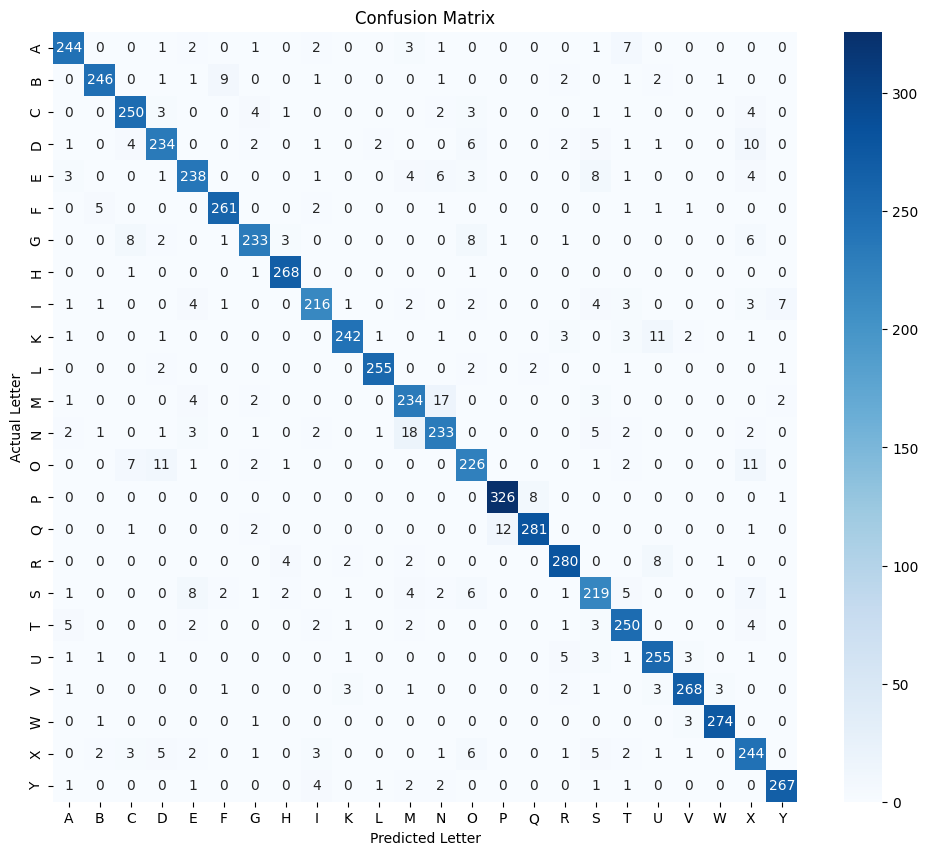

In [27]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_knn.classes_, yticklabels=best_knn.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual Letter')
plt.xlabel('Predicted Letter')
plt.show()

In [29]:
joblib.dump(best_knn, 'sibi_knn.pkl')

['sibi_knn.pkl']